# Week 1 - Preprocessing

## Please run the cells of the notebook as you get to them while reading

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

# Addiitional imports
import tkinter as tk
from tkinter import simpledialog, messagebox
from IPython.display import clear_output

#### Notes on changed cells in this notebook. 

I added markdown to this notebook to malke it easier to navigate (otherwise I conntinually found myself scrolling back and forth to find a specific reference). For instance, I added four(4) pound signs (\#\#\#\#) to the numbered cells to differentiate them.

For some of the code cells I added, I also added a markdown cell with five(5) pound signs (\#\#\#\#\#).

Additionally I added a few imports as this notebook did not specifically ask us not to do so.

I left in a couple of charts/graphs/code cells that are probably of no use, but helped me to see correlations within the dataset.

# 1. Lesson on how to search for Python commands

Let's consider a few possible ways to learn about Python programming.  Let's suppose you want to learn how to produce a short summary of the information in your DataFrame.

1. Your **instructor** could provide the information.

You could be provided with a lesson about functions like info() and describe().  If you have a pandas DataFrame called df, then you can summarize its contents using df.info() or df.describe().  df.info() provides a list of column names with their counts and data types.  df.describe() will provide information such as the mean, min, max, standard deviation, and quantiles.  Thus:

In [2]:
df = pd.DataFrame([[1, 4], [2, 5], [3, 6], [4, 7]], columns = ['A', 'B'])
df.describe()

,A,B
count,4.000000,4.000000
mean,2.500000,5.500000
std,1.290994,1.290994
min,1.000000,4.000000
25%,1.750000,4.750000
50%,2.500000,5.500000
75%,3.250000,6.250000
max,4.000000,7.000000


In this describe() result, we see that the two columns A and B each have four elements.  The means and other statistics are shown.

2. You could look up the information on **Google**.

If I Google the question "how do I briefly summarize the contents of a dataframe using Python," I receive the following link (among others), which discusses the describe() command mentioned above:

https://www.w3schools.com/python/pandas/ref_df_describe.asp

It also provide the complete usage information:

dataframe.describe(percentiles, include, exclude, datetime_is_numeric)

It explains that "percentiles" is set by default to [0.25, 0.5, 0.75] but we could change that.  Let's try it!  Since there are three intervals here rather than four, it might be more meaningful to ask about a 33rd and 67th percentile rather than 25, 50, and 75.  We can use 1/3 for 0.33 and 2/3 for 0.67 to get the exact percentile values.

In [3]:
df = pd.DataFrame([[1, 4], [2, 5], [3, 6], [4, 7]], columns = ['A', 'B'])
df.describe(percentiles = [1/3, 2/3])

,A,B
count,4.000000,4.000000
mean,2.500000,5.500000
std,1.290994,1.290994
min,1.000000,4.000000
33.3%,2.000000,5.000000
50%,2.500000,5.500000
66.7%,3.000000,6.000000
max,4.000000,7.000000


Apparently, the 50% value (the median) stays even though we did not specifically request it.

3. You could look up the official **documentation**.

Now that we know we want the pandas describe() function, try Googling: pandas documentation describe.

Here is the general documentation page for pandas:

https://pandas.pydata.org/docs/index.html

Here is the specific page for the describe() function:

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html

When I look at this, it appears to be showing the most recent (currently 2.2) version of pandas; this is shown in the upper right corner.

4. You could also ask **ChatGPT**.

Let's try it.  ChatGPT, "how do I briefly summarize the contents of a dataframe using Python"

When I do this, ChatGPT mentions describe() among other options, but does not go into detail.  However, I could ask it.  ChatGPT, "tell me more about describe() in Python for summarizing dataframes."

Then, I get a good explanation of describe(), although it does not mention the percentiles option.  One advantage of using Google or the documentation in addition of ChatGPT is that these sources may provide interesting information that does not directly answer our question.  Thus, we might not have known about the various arguments, such as percentiles, if we only used ChatGPT.  A second issue is that ChatGPT sometimes hallucinates (it makes up information).  In general, by examining multiple sources - Google, documentation, and ChatGPT - we can get more information.

# 2. Weekly graph question

In Storytelling With Data, on page 1: examine the pie chart graph in the upper left corner of the graphs.  Please write a short explanation of the pros and cons of this graph.  What do you think of the choice of pie chart as a format?  The color scheme?  The legend?  The title?  How would you draw it differently if you were creating this graph?

To be perfectly honest, I have already finished the book (I thought I might get ahead with the reading). In her book the author comes out vehemently against pie graphs for any number of reasonns. I believe that the two that hit home the most for me were 
1. Pie graphs can be deceptive in how they protray the data
2. Pie graphs are inherently harder to read than some other graphs

Beyond this she had more reasons not to ever use pie graphs. Although I have tended toward them in the past, her arguments are more than good enough to convince me other ways of visualizing information are better at getting across the story you wish your data to tell. 

So to answer the quesstions:
<ol>
<li>Pie charts are not the best choice as a format</li>
<li>The colors are okay, but aas the author later suggests, using a single color with varying shades or using something unobtrusive like grey and another color that would make the section of the chart you are trying to emphasize stand out, might be a better choice.</li>
<li>The Legend is okay, BUT it is not ordered in such a way as to make reading it easy on the viewer/consumer of the graph. Simply, it doesn't tell the story.</li>
<li>The title is at best good. The title should be a "call to action." This title does not capitalize on the preattentive attributes the author speaks about later on.</li>
<li>There are several ways I would do this differently.</li> 
  <ol>
  <li>I would use a different <u>graph tpe</u>, such as a histogram/bar graph (I am most impressed by the horizontal bar graphs the author shows in the book)</li>
  <li>In line with her other suggestions I would use <u>variations of one color</u> to emphasize the story I wish to tell with possibly a second color to depict the specific area I wish the audience to concentrate on.</li>
  <li>The <u>legend</u> can be used at the end of the horizontal bar graph</li>
  <li>The <u>title</u> might be a call to action similar to the one the author suggested, "Reason for continuing funding." Or something similar.</li>
  </ol>
</ol>


# 3. Homework - Bank Customers

I will begin by creating a file for you to analyze.  I will show you all of the steps I used to create it.  Please run this code in order to create and save a file about bank customers.

### The numbered problems are for you to solve.

In [4]:
num_customers = 100
np.random.seed(0)

In [5]:
df_bank = pd.DataFrame(columns = ["CustomerID"])

In [6]:
df_bank["CustomerID"] = [str(x) for x in np.arange(num_customers)]

In [7]:
start = datetime(1950, 1, 1)
end = datetime(2024, 1, 1)
numdays = (end - start).days
random_days = np.random.randint(0, numdays, size = num_customers)
df_bank["BirthDate"] = start + pd.to_timedelta(random_days, unit='D')
df_bank["BirthDate"] = df_bank["BirthDate"].dt.strftime('%Y-%m-%d')

In [8]:
def make_ssn_string(num):
    ssn_str = f'{num:09}'
    return ssn_str[0:3] + "-" + ssn_str[3:5] + "-" + ssn_str[5:9]
ssn_vector_func = np.vectorize(make_ssn_string)
df_bank["SSN"] = ssn_vector_func(np.random.randint(0, 999999999, size = num_customers))

In [9]:
df_bank["AccountID"] = np.random.randint(0, num_customers, size = num_customers)

In [10]:
random_days = np.random.randint(0, 365 * 80, size = num_customers)
df_bank["AccountOpened"] = (pd.to_datetime(df_bank["BirthDate"]) + pd.to_timedelta(random_days, unit='D')).dt.strftime('%Y-%m-%d')

In [11]:
df_bank.loc[0, "BirthDate"] = "1980"
df_bank.loc[1, "BirthDate"] = "no date"

In [12]:
df_bank.loc[2, "AccountID"] = np.nan

In [13]:
df_bank["AccountType"] = np.random.choice(["checking", "savings", "cd"], size = num_customers)

Load the bank_customers.csv file.  (There is no practical reason to save it, then load it - we're just demonstrating how this would be done.)
I am calling the loaded df by a new name, df_bank_loaded, to make clear why it's not the same variable as the old df.  Of course, in actuality the two contain the exact same data!  But it's good to get in the habit of naming things carefully.

In [14]:
df_bank.loc[num_customers - 1] = df.loc[0]
df_bank.to_csv("bank_customers.csv", index=False)

In [15]:
df_bank_loaded = pd.read_csv("bank_customers.csv")

#### 1. Use describe() and info() to analyze the data.   Also, look at the first few rows.

In [16]:
df_bank_loaded.describe()

,CustomerID,AccountID
count,99.000000,98.000000
mean,49.000000,46.551020
std,28.722813,27.679358
min,0.000000,0.000000
25%,24.500000,25.500000
50%,49.000000,42.000000
75%,73.500000,71.000000
max,98.000000,97.000000


In [17]:
df_bank_loaded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CustomerID     99 non-null     float64
 1   BirthDate      99 non-null     object 
 2   SSN            99 non-null     object 
 3   AccountID      98 non-null     float64
 4   AccountOpened  99 non-null     object 
 5   AccountType    99 non-null     object 
dtypes: float64(2), object(4)
memory usage: 4.8+ KB


Suggested Google Search or ChatGPT prompt: "how do I use the describe function in python"

Example Google result: https://www.w3schools.com/python/pandas/ref_df_describe.asp

In [18]:
# The first few rows
df_bank_loaded.iloc[0:5]

,CustomerID,BirthDate,SSN,AccountID,AccountOpened,AccountType
0,0.0,1980,530-47-1866,4.0,1959-12-06,checking
1,1.0,no date,682-76-9175,67.0,2039-02-20,cd
2,2.0,1976-12-15,377-98-9839,NaN,2019-03-25,checking
3,3.0,2003-10-18,474-05-7613,86.0,2004-03-02,cd
4,4.0,1985-12-06,750-55-5509,77.0,2059-05-05,cd


If you used describe() and info(), you now know that BirthDate and AccountOpened are strings.  But we want them to be dates.  Let's convert them to dates (or Timestamps in pandas).  When we try this, we get a ValueError.

In [19]:
try:
    df_bank_loaded["BirthDate"] = pd.to_datetime(df_bank_loaded["BirthDate"], format='%Y-%m-%d')
    print("It worked!")
except ValueError as e:
    print(f"ValueError for BirthDate: {e}")

ValueError for BirthDate: time data "1980" doesn't match format "%Y-%m-%d", at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.


In [20]:
try:
    df_bank_loaded["AccountOpened"] = pd.to_datetime(df_bank_loaded["AccountOpened"], format='%Y-%m-%d')
    print("It worked!")
except ValueError as e:
    print(f"ValueError for AccountOpened: {e}")

It worked!


The simple way to fix this is to remove the rows that have bad dates for BirthDate.  I Googled:

"How to remove rows from a dataframe that have poorly formatted dates using python"

https://stackoverflow.com/questions/21556744/pandas-remove-rows-whose-date-does-not-follow-specified-format

This recommends that I verify that the date is a string of length 10, because YYYY-MM-DD has that length:

df1\[df1.BirthDate.str.len() !=10]

In [21]:
df_bank_loaded[df_bank_loaded.BirthDate.str.len() != 10]

,CustomerID,BirthDate,SSN,AccountID,AccountOpened,AccountType
0,0.0,1980,530-47-1866,4.0,1959-12-06,checking
1,1.0,no date,682-76-9175,67.0,2039-02-20,cd
99,NaN,NaN,NaN,NaN,NaT,NaN


In [22]:
len(df_bank_loaded[df_bank_loaded.BirthDate.str.len() == 10])

97

In [23]:
df_bank_loaded[df_bank_loaded.BirthDate.str.len() != 10].iloc[0:5]

,CustomerID,BirthDate,SSN,AccountID,AccountOpened,AccountType
0,0.0,1980,530-47-1866,4.0,1959-12-06,checking
1,1.0,no date,682-76-9175,67.0,2039-02-20,cd
99,NaN,NaN,NaN,NaN,NaT,NaN


Now we can make this permanent, creating a new DataFrame df_bank_datefix.
I am making a copy in order to ensure that df_bank_datefix is a new DataFrame rather than being a slice of the old one.

In [24]:
df_bank_datefix = df_bank_loaded[df_bank_loaded.BirthDate.str.len() == 10].copy()

Test again:

In [25]:
try:
    df_bank_datefix["BirthDate"] = pd.to_datetime(df_bank_datefix["BirthDate"], format='%Y-%m-%d')
    print("It worked!")
except ValueError as e:
    print(f"ValueError: {e}")

It worked!


#### 2. To check that it worked, use a summary function that will tell you if the BirthDate field is now a datetime type

In [26]:
df_bank_datefix.info()

<class 'pandas.core.frame.DataFrame'>
Index: 97 entries, 2 to 98
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   CustomerID     97 non-null     float64       
 1   BirthDate      97 non-null     datetime64[ns]
 2   SSN            97 non-null     object        
 3   AccountID      96 non-null     float64       
 4   AccountOpened  97 non-null     datetime64[ns]
 5   AccountType    97 non-null     object        
dtypes: datetime64[ns](2), float64(2), object(2)
memory usage: 5.3+ KB


#### 3. Check whether there are any null values in the DataFrame.  If so, remove those rows or (if you prefer) fill in the value with an appropriate number.

First try at a Google search or ChatGPT prompt: "how do I find out if there are any null values in a pandas DataFrame?"

This page gives an answer.  Unfortunately, it took my request too literally: it tells me only if there are any, and not which rows have them.  On reflection, that's not really what I want - I think I asked the wrong question.  I want to see the rows, not just _whether_ there are any.

https://stackoverflow.com/questions/29530232/how-to-check-if-any-value-is-nan-in-a-pandas-dataframe

ChatGPT likewise doesn't give the answer I want - because I asked the wrong question.

Next try at a Google search or ChatGPT prompt: "how do I check which rows have null values in a pandas DataFrame?"

This page gives an answer:

https://stackoverflow.com/questions/36226083/how-to-find-which-columns-contain-any-nan-value-in-pandas-dataframe

ChatGPT also gives a good answer.  I recommend looking at both of them!

Now try it on your own:

Suggested Google search or ChatGPT prompt: "how do I remove rows with null values in a pandas DataFrame?"

Suggested Google search or ChatGPT prompt: "how do I fill in null values in a pandas DataFrame?"

In [27]:
mask = df_bank_datefix.isna().any(axis=1)  

# View those rows
df_null_rows = df_bank_datefix[mask]

# show the rows with nulls
df_null_rows

,CustomerID,BirthDate,SSN,AccountID,AccountOpened,AccountType
2,2.0,1976-12-15,377-98-9839,NaN,2019-03-25,checking


In [28]:
# Show which feature has a null value

df_bank_datefix.isna().any()[lambda x: x]


AccountID    True
dtype: bool

In [29]:
# drop any row where 'col' is null
col = 'AccountID'
df_clean = df_bank_datefix.dropna(subset=[col])
df_clean.describe()

,CustomerID,BirthDate,AccountID,AccountOpened
count,96.000000,96,96.000000,96
mean,50.500000,1990-07-31 22:45:00,46.781250,2034-01-31 08:30:00
min,3.000000,1952-01-26 00:00:00,0.000000,1953-05-05 00:00:00
25%,26.750000,1974-12-03 18:00:00,26.500000,2011-06-02 00:00:00
50%,50.500000,1991-08-30 00:00:00,42.000000,2032-10-29 00:00:00
75%,74.250000,2005-02-28 06:00:00,71.500000,2061-09-17 00:00:00
max,98.000000,2023-12-26 00:00:00,97.000000,2095-12-10 00:00:00
std,27.856777,NaN,27.545638,NaN


#### 4. Find out if there are any duplicate rows (two rows exactly the same).  List their row numbers.  Then remove the duplicates

Suggested Google search or ChatGPT prompt: "how can I find out if there are any duplicate rows in a DataFrame using Python"

Again, Google provides me with a page that addresses the question:

https://saturncloud.io/blog/how-to-find-all-duplicate-rows-in-a-pandas-dataframe/

To remove the duplicates, do this search: "how can I remove the duplicate rows in a DataFrame using Python"

This leads me to the following documentation.

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop_duplicates.html

In [30]:
# Mark all instances of duplicates as True
mask_dup = df_clean.duplicated(keep=False)

# View the duplicate rows
duplicates = df_clean[mask_dup]
duplicates

,CustomerID,BirthDate,SSN,AccountID,AccountOpened,AccountType


In [31]:
duplicates = df_clean.drop_duplicates()
duplicates

,CustomerID,BirthDate,SSN,AccountID,AccountOpened,AccountType
3,3.0,2003-10-18,474-05-7613,86.0,2004-03-02,cd
4,4.0,1985-12-06,750-55-5509,77.0,2059-05-05,cd
5,5.0,2008-02-29,671-43-0485,75.0,2025-05-03,checking
6,6.0,1975-04-05,288-62-9296,56.0,2048-09-21,savings
7,7.0,2016-06-18,593-49-1249,16.0,2087-07-24,savings
...,...,...,...,...,...,...
94,94.0,1969-03-14,958-12-8308,5.0,2037-04-03,savings
95,95.0,1975-09-23,607-97-1651,36.0,2011-07-24,checking
96,96.0,1989-03-09,870-80-0364,0.0,2054-11-01,cd
97,97.0,1960-09-23,773-33-2797,75.0,1993-09-16,cd


#### 5. Check whether the customers all have unique AccountIDs.  If not, provide the first example of a non-unique AccountId.

Suggested Google search or ChatGPT prompt: "how can I find the first non-unique item from a pandas Series in python"

By the way: why didn't I ask the question "how can I check whether the customers all have unique AccountIDs"?

The problem would be that Google and ChatGPT don't know what "customers" you are talking about.  It's important to understand that the AccountIDs are a column of a DataFrame, and as such they are a Series.  Therefore, we should use the correct vocabulary and ask about a Series.  If you mess up and ask about a "list" instead of a Series, you _might_ get an answer that still works.  But it's better to get the vocabularly right.

It's important to add "in python" because this task could be performed in many languages.

ChatGPT gave me this suggestion: data[data.isin(data[data.duplicated()])].iloc[0]
However, ChatGPT did not explain how this code worked and even claimed (falsely) that it was going to use the value_counts() function in the solution.  So although the code is correct, I personally found ChatGPT's answer very confusing.  You could, perhaps, ask ChatGPT to explain further how this code works.

ChatGPT, "How does this code work: data[data.isin(data[data.duplicated()])].iloc[0]"

On the other hand, Google leads me to the documentation for the duplicated() function:

https://pandas.pydata.org/docs/reference/api/pandas.Series.duplicated.html

Here, I can see that when I really need is data.duplicated(keep = False), where "data" should be the Series in question.  However, this just gives me a Series of boolean values indicating which ones are duplicates.  I have to somehow know that extracting the numerical values instead of a Series of booleans involves boolean indexing: data\[data.duplicated(keep = False)].

So as usual, I'd suggest that a combination of Google, documentation, and ChatGPT will give you the best information.

In [32]:
duplicates[duplicates.isin(duplicates[duplicates.duplicated()])].iloc[0]

CustomerID       NaN
BirthDate        NaT
SSN              NaN
AccountID        NaN
AccountOpened    NaT
AccountType      NaN
Name: 3, dtype: object

In [33]:
col = "AccountID"

if df_clean[col].is_unique:
    print("All AccountIDs are unique.")
else:
    dup_rows = df_clean[df_clean[col].duplicated(keep=False)]
    first_dup = dup_rows.iloc[0]           # first example row with a non-unique AccountID
    print("First non-unique AccountID:", first_dup[col])
    display(first_dup)                     # shows the full row

First non-unique AccountID: 86.0


CustomerID                       3.0
BirthDate        2003-10-18 00:00:00
SSN                      474-05-7613
AccountID                       86.0
AccountOpened    2004-03-02 00:00:00
AccountType                       cd
Name: 3, dtype: object

#### 6. Count how many distinct AccountIDs there are.

Suggested Google search or ChatGPT prompt: "how can I find out how many distinct items there are in a pandas Series using python"

This time Google provides me with a page that's specifically made to answer this question:

https://www.geeksforgeeks.org/how-to-count-distinct-values-of-a-pandas-dataframe-column/

In [34]:
# Count unique values in 'AccountID' column using unique()
n = len(pd.unique(df_clean['AccountID']))

print("Number of unique values in column 'AccountID':", n)

Number of unique values in column 'AccountID': 63


#### 7. Remove the duplicate AccountIDs so that each AccountID appears only once.

This will involve using data.duplicated() but this time without keep = False.  We don't want to drop all duplicates; we want to leave one example of each value.

In [35]:
# Remove duplicate AccountIDs, keeping only the first occurrence of each
df_cleaner = df_clean[~df_clean['AccountID'].duplicated()].copy()

print(f"Original rows: {len(df_clean)}")
print(f"After removing duplicates: {len(df_cleaner)}")
print(f"Removed {len(df_clean) - len(df_cleaner)} duplicate rows")

Original rows: 96
After removing duplicates: 63
Removed 33 duplicate rows


#### 8. What are the mean, median, and mode customer age in years?  (Rounding down to the next lower age.)
Are there any outliers?  (Customers with very large or very small ages, compared with the other ages?)

Suggested Google search or ChatGPT prompt: "how can I find out the mean, median, and mode of a pandas Series"

In [36]:

from scipy import stats

# Calculate customer age in years, rounded down
today = pd.Timestamp.now()
df_clean_age = df_cleaner.copy()
df_clean_age['Age'] = (today - df_clean_age['BirthDate']).dt.days // 365

# Get the age Series
ages = df_clean_age['Age']

# Calculate mean, median, and mode
mean_age = ages.mean()
median_age = ages.median()
mode_result = stats.mode(ages, keepdims=True)
mode_age = mode_result.mode[0]

print(f"Mean age: {mean_age:.2f}")
print(f"Median age: {median_age}")
print(f"Mode age: {mode_age}")

# Check for outliers using IQR method
minimum = ages.min() + 5
maximum = ages.max() - 5

lower_bound = minimum - 1.5
upper_bound = maximum + 1.5

outliers = ages[(ages < lower_bound) | (ages > upper_bound)]
print(f"\nOutlier bounds: [{lower_bound}, {upper_bound}]")
print(f"Number of outliers: {len(outliers)}")
if len(outliers) > 0:
    print(f"Outlier ages: {sorted(outliers.values.tolist())}")
else:
    print("No outliers found.")


Mean age: 37.78
Median age: 35.0
Mode age: 29

Outlier bounds: [5.5, 70.5]
Number of outliers: 5
Outlier ages: [2, 3, 71, 73, 74]


#### 9. One-hot encode the AccountType column.  This means creating a new "checking," "savings", and "cd" columns so that you can run machine learning algorithms.

In [37]:
df1 = df_cleaner.copy()
df2 = df1.copy()

one_hot = pd.get_dummies(df1["AccountType"])
df2 = df2.join(one_hot)
df2.iloc[0:5]

,CustomerID,BirthDate,SSN,AccountID,AccountOpened,AccountType,cd,checking,savings
3,3.0,2003-10-18,474-05-7613,86.0,2004-03-02,cd,True,False,False
4,4.0,1985-12-06,750-55-5509,77.0,2059-05-05,cd,True,False,False
5,5.0,2008-02-29,671-43-0485,75.0,2025-05-03,checking,False,True,False
6,6.0,1975-04-05,288-62-9296,56.0,2048-09-21,savings,False,False,True
7,7.0,2016-06-18,593-49-1249,16.0,2087-07-24,savings,False,False,True


Now, change the cd, checking, and savings columns into integers.

In [38]:
df2['checking'] = df2['checking'].astype(int)
df2['savings'] = df2['savings'].astype(int)
df2['cd'] = df2['cd'].astype(int)

#### 10. Are there any other data values that do not seem right?  If not, give an example?

In [39]:
df2

,CustomerID,BirthDate,SSN,AccountID,AccountOpened,AccountType,cd,checking,savings
3,3.0,2003-10-18,474-05-7613,86.0,2004-03-02,cd,1,0,0
4,4.0,1985-12-06,750-55-5509,77.0,2059-05-05,cd,1,0,0
5,5.0,2008-02-29,671-43-0485,75.0,2025-05-03,checking,0,1,0
6,6.0,1975-04-05,288-62-9296,56.0,2048-09-21,savings,0,0,1
7,7.0,2016-06-18,593-49-1249,16.0,2087-07-24,savings,0,0,1
...,...,...,...,...,...,...,...,...,...
88,88.0,1962-02-07,327-09-3267,97.0,1989-10-03,cd,1,0,0
90,90.0,1969-06-18,395-31-7064,34.0,2010-12-28,checking,0,1,0
94,94.0,1969-03-14,958-12-8308,5.0,2037-04-03,savings,0,0,1
95,95.0,1975-09-23,607-97-1651,36.0,2011-07-24,checking,0,1,0


In [40]:
# Days since account opened; identify any future (negative) dates

opened = pd.to_datetime(df_clean['AccountOpened'])
today = pd.to_datetime('today')
days_since_open = (today - opened).dt.days
# Find rows where the difference is <= 0 (accounts opened in the future or today)
future_or_today = days_since_open <= 0
print("The following", future_or_today.sum(), "accounts have an AccountOpened date in the future or today:")
# Offending rows
future_rows = df_clean.loc[future_or_today, ['AccountOpened']]
future_rows

The following 58 accounts have an AccountOpened date in the future or today:


,AccountOpened
4,2059-05-05
6,2048-09-21
7,2087-07-24
8,2046-11-17
9,2048-06-01
11,2036-03-17
15,2031-01-21
16,2047-01-25
17,2063-08-28
18,2070-08-26


I don't think Google or ChatGPT alone will help you here.  To answer the question, look at the columns and think about what relationships they should have with each other.  For example, it seems reasonable to expect that BirthDate would be no earlier than 120 years ago (it's unlikely that a customer would be this old.)  Now we can ask Google:

"How can I find out how long ago a pandas date is"

Google provides this helpful link, although it is not exactly the solution - you'll have to work with it a bit:

https://stackoverflow.com/questions/26072087/pandas-number-of-days-elapsed-since-a-certain-date

If you check, I think you'll find that all dates are more recent than 120 years ago.  What about the AccountOpened columns?  I see some obviously wrong dates there just by looking at the first few rows.

Along those same lines, are there any birth dates that are too recent?  Do we think that any two year olds will have opened bank accounts?  How common do you think this is in real life?  How common is it in our data set?  Can you detect the two year olds opening bank accounts using just one column, or do you need two columns?

In [41]:
def is_younger_than(birthdate, age=None, check_future=False):
    today = pd.to_datetime("today")
    if pd.isna(birthdate):
        return np.nan
    birthdate = pd.to_datetime(birthdate)
    
    if check_future:
        # Check if birthdate is in the future
        return birthdate > today
    else:
        client_age = round((today - birthdate).days / 365.25, 2)
        # print(f"Client age: {client_age}")
        return client_age < age

In [42]:
# Find future birthdates
future_mask = df2['BirthDate'].apply(lambda bd: is_younger_than(bd, check_future=True))
future_mask_true = df2[future_mask]
future_mask_true

,CustomerID,BirthDate,SSN,AccountID,AccountOpened,AccountType,cd,checking,savings


##### Find customerrs younger than a given age

In [43]:
# Find all customers younger than defined age
# this prints the number of customers under the age given

"""
# Code below uses tkinter to prompt for age input for compiled windowed scripts
# uncomment to use

root = tk.Tk()
root.withdraw()  # Hide main window
age_to_check = simpledialog.askstring("Input", "Enter the age of the customer you wish to check (Defaults to 5):")
"""

"""
# code below uses input() for age input for Jupyter notebooks
# uncomment to use

age_to_check = input("Enter the age of the customer you wish to check (defaults to 5): ")   
                          
if age_to_check is None or age_to_check.strip() == "":
	age_to_check = 5
else:
	try:
		age_to_check = int(age_to_check)
	except ValueError:
		age_to_check = 5
"""  

age_to_check = 5
young_customers = df2[df2['BirthDate'].apply(lambda bd: is_younger_than(bd, age_to_check))]
print(f"Number of customers younger than", age_to_check,":", len(young_customers))

Number of customers younger than 5 : 2


#### 11. Use Matplotlib and/or Seaborn to analyse the ages at which customers open their account.  Is there a connection between the year they are born vs. the age at which they open the account?  Graph this in whatever way you think is best.

##### Correlation Matrix

Correlation Matrix:
            CustomerID  AccountID        cd  checking   savings
CustomerID    1.000000  -0.147604 -0.030986  0.158171 -0.135937
AccountID    -0.147604   1.000000  0.221418 -0.039132 -0.183168
cd           -0.030986   0.221418  1.000000 -0.535000 -0.448158
checking      0.158171  -0.039132 -0.535000  1.000000 -0.515494
savings      -0.135937  -0.183168 -0.448158 -0.515494  1.000000


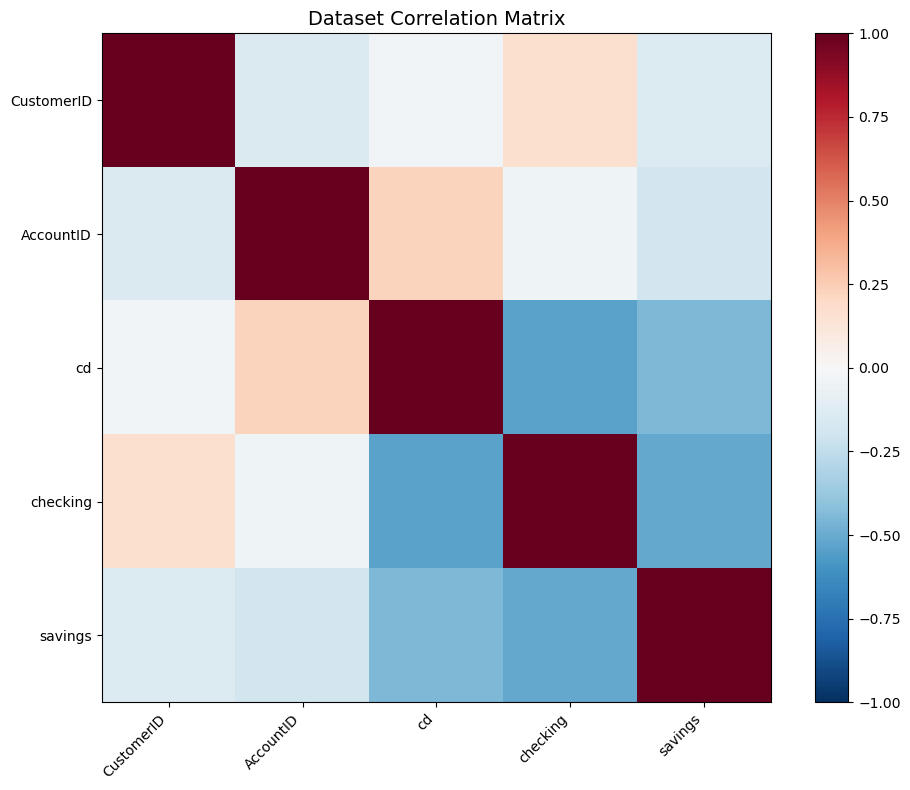

In [44]:
df2_copy = df2.copy()
numeric_columns = df2_copy.select_dtypes(include=['int64', 'float64']).columns.tolist()
df2_numeric = df2_copy[numeric_columns]

correlation_matrix = df2_numeric.corr()
print("Correlation Matrix:")
print(correlation_matrix)

# Visualize the correlation matrix using matplotlib
plt.figure(figsize=(10, 8))
cmap = plt.cm.RdBu_r

# Plot the heatmap
im = plt.imshow(correlation_matrix, cmap=cmap, vmin=-1, vmax=1)
plt.colorbar(im)

plt.title('Dataset Correlation Matrix', fontsize=14)
plt.xticks(np.arange(len(numeric_columns)), numeric_columns, rotation=45, ha='right')
plt.yticks(np.arange(len(numeric_columns)), numeric_columns)

# set and print the plot
plt.tight_layout()
plt.show()
plt.close()

I asked Google and ChatGPT: "How can I plot dates vs. dates in Matplotlib".  This gave me a hard time at first - I had to tell ChatGPT it was giving me the wrong information because it tried to plot dates vs. numbers.  Eventually, I found out that you plot dates vs. dates in the same way you'd plot numbers vs. numbers.

Think in terms of Storytelling With Data to plot these as best you can.  Once you've seen the result, try to think of the best way to plot the data so as to show the user what you want them to see.  Title the graph so as to display the lesson that you want the user to take away.
Here are some options for the axes:

1. A scatter or line plot: On the x-axis, the date they are born.  On the y-axis, the date they open the account.
2. A scatter or line plot: On the x-axis, the date they are born.  On the y-axis, the age in years at which they open the account.
3. A scatter or line plot: On the x-axis, they year (integer) they are born.  On the y-axis, the age in years at which they open the account.
4. A histogram: on the x-axis, the age at which they open the account.

Here is an example:

##### Plot of Customer Age vs. Account Opened Date

##### I played around with this and ended up writing this function

The function chooses a column from a list of columns in the dataset. I currently have it set to run in windowed mode. 

In [45]:
# Function to choose a column from the dataframe

def choose_column(df):

    available_cols = [col for col in df.columns]
    
    """
    # below code for windowed scripts using tkinter
    
    root = tk.Tk()
    root.withdraw()  # Hide main window
    dict_numeric_cols = {}
    
    selection = simpledialog.askstring(
    "Choose Column",
    "Available columns:\n" + "\n".join(f"[{i}] {col}" for i, col in enumerate(available_cols, start=1)) +
    "\n\nEnter the number of the target column (default=1): "
    )
    """
    for idx, col in enumerate(available_cols, start=1):
        print(f"[{idx}] {col}")
    selection = input("Enter the number of the selected column (default=1): ")
    selection = selection.strip() if selection else ""
    if selection == "":
        selection = 1
    try:
        selection = int(selection)
        column = available_cols[selection - 1]
    except (ValueError, IndexError):
        print("Invalid selection; defaulting to the first column.")
        column = available_cols[0]

    return column

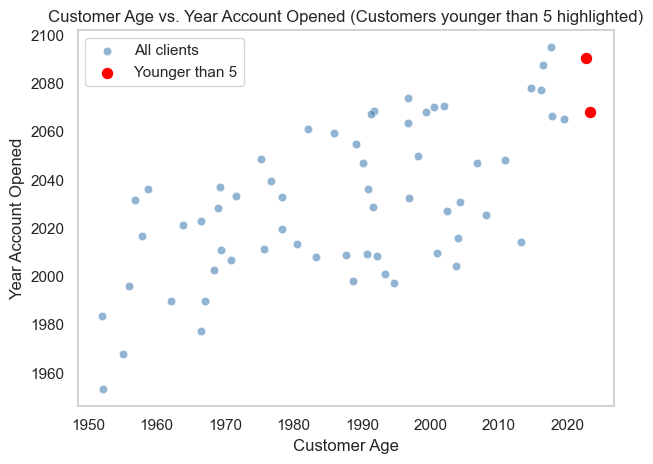

In [46]:
import seaborn as sns

sns.set_theme(style="whitegrid")    

# Create side-by-side bar chart with actual values


""""
# Following code makes this interactive 
# remove the triple quotes to enable interactivity and delete the two lines below the last triple quotes
#
first_column_to_check = choose_column(df2)
clear_output()
second_column_to_check = choose_column(df2)
clear_output()
"""
first_column_to_check = "AccountOpened"
second_column_to_check = "BirthDate"

y = df2[first_column_to_check]
x = df2[second_column_to_check]

"""
# Code below uses tkinter to prompt for age input for compiled windowed scripts
# uncomment to use

root = tk.Tk()
root.withdraw()  # Hide main window
age_to_check = simpledialog.askstring("Input", "Enter the age of the customer you wish to check")
"""

"""
# code below uses input() for age input for Jupyter notebooks
# uncomment to use

age_to_check = input("Enter the age of the customer you wish to check (default=5): ")  
                           
if age_to_check is None or age_to_check.strip() == "":
	age_to_check = 5
else:
	try:
		age_to_check = int(age_to_check)
	except ValueError:
		age_to_check = 5
"""

# Build a mask for clients younger than the threshold
age_to_check = 5
age_mask = x.apply(lambda bd: is_younger_than(bd, age_to_check))

# Base scatter
ax = sns.scatterplot(x=x, y=y, color='steelblue', alpha=0.6, label='All clients')

# Overlay highlighted points for those younger than threshold
sns.scatterplot(x=df2.loc[age_mask, second_column_to_check],
                y=df2.loc[age_mask, first_column_to_check],
                color='red', s=80, label=f'Younger than {age_to_check}', ax=ax)

ax.set_xlabel("Customer Age") 
ax.set_ylabel("Year Account Opened") 
ax.grid(False)

if age_to_check:
    plt.title(f"Customer Age vs. Year Account Opened (Customers younger than {age_to_check} highlighted)")
else:
    plt.title("Customer Age vs. Year Account Opened")
plt.tight_layout()
plt.show()
plt.close()


# 4. Storytelling With Data graph

Choose any graph in the Introduction of Storytelling With Data.  Using matplotlib to reproduce it in a rough way.  I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph.  However, if you're excited about learning to use matplotlib, this is a good way to do that.  You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

In [47]:
# Create dataframe from storytelling with data graph
data = {
    'Category': ['Bored', 'Not great', 'OK', 'Kind of interested', 'Excited'],
    'Before': [11, 5, 40, 25, 19],
    'After': [12, 6, 14, 30, 38]
}

df_storytelling = pd.DataFrame(data)
print(df_storytelling)


             Category  Before  After
0               Bored      11     12
1           Not great       5      6
2                  OK      40     14
3  Kind of interested      25     30
4             Excited      19     38


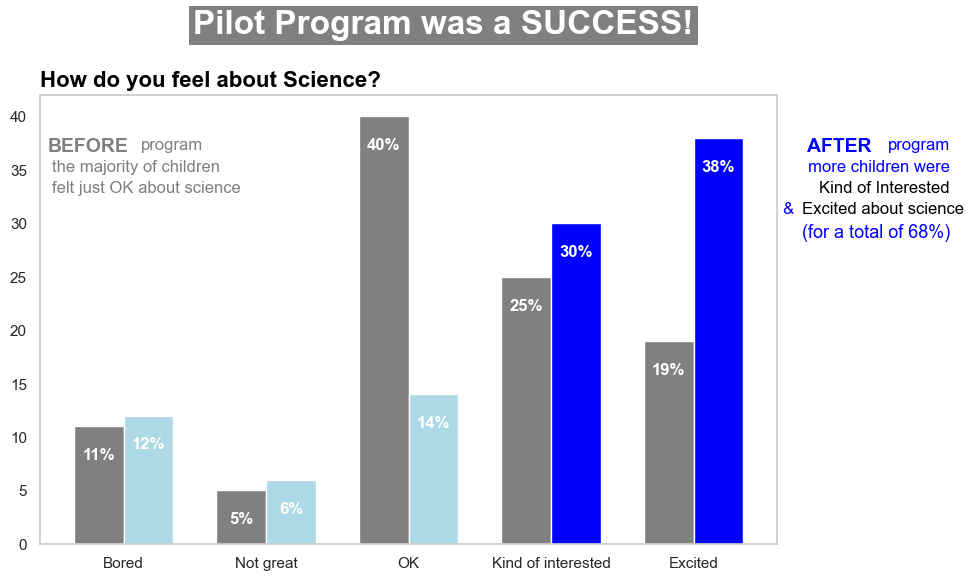

In [48]:
x = np.arange(len(df_storytelling['Category']))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Create colors for highlighting specific bars
# All bars start as grey, then we highlight specific ones
before_colors = ['grey'] * len(df_storytelling['Category'])
after_colors = ['grey'] * len(df_storytelling['Category'])

# Highlight the "Excited" category (index 4) and the "Kind of interested" (index 3) to emphasize the positive change
after_colors[4] = 'blue' 
after_colors[3] = 'blue'
# Highlight the "OK" category (index 2), "Not great" (index 1), and "Bored" (index 0) in a lighter shade 
after_colors[2] = 'lightblue'
after_colors[1] = 'lightblue'
after_colors[0] = 'lightblue' 

bars1 = ax.bar(x - width/2, df_storytelling['Before'], width, label='Before', color=before_colors)
bars2 = ax.bar(x + width/2, df_storytelling['After'], width, label='After', color=after_colors)

# Add data labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        offset = 2 # offset from top of bar
        ax.text(bar.get_x() + bar.get_width() / 2,
                height - offset,          # move label down
                f"{int(height)}%",
                ha="center",
                va="top",                 # anchor to top of text
                fontsize=12,
                font="arial",
                fontweight="bold",
                color="white"
                )

# ax.set_ylabel('Percentage (%)')
ax.set_title('How do you feel about Science?', color='black', fontsize=16, fontweight='bold', loc='left')
ax.set_xticks(x)
ax.set_xticklabels(df_storytelling['Category'], ha='center')

# Add text annotations on left and right sides
beforeword = 'BEFORE'
before_line2 = 'program'
before_line3 = 'the majority of children'
before_line4 = 'felt just OK about science'
afterword = 'AFTER'
after_line2 = 'program'
after_line3 = 'more children were'
after_line4 = 'Kind of Interested'
after_line5 = '&'
after_line6 = 'Excited about science'
after_line7 = '(for a total of 68%)'
spaces = '                                   '
success_text = 'Pilot Program was a SUCCESS!'
# success = spaces + success_text + spaces

# Question at the top
ax.text(4, 50, success_text,fontsize=24, ha='right', va='top', color='white', weight='bold', bbox=dict(facecolor='grey', edgecolor='none', pad=3))

# Left side with bold BEFORE
ax.text(-0.53, 38, beforeword, fontsize=14, ha='left', va='top', color='grey', weight='bold')
ax.text(0.125, 38, before_line2, fontsize=12, ha='left', va='top', color='grey')
ax.text(-0.5, 36, before_line3, fontsize=12, ha='left', va='top', color='grey')
ax.text(-0.5, 34, before_line4, fontsize=12, ha='left', va='top', color='grey')

# Right side with bold AFTER
ax.text(5.25, 38, 'AFTER', fontsize=14, ha='right', va='top', color='blue', weight='bold')
ax.text(5.8, 38, after_line2, fontsize=12, ha='right', va='top', color='blue')
ax.text(5.8, 36, after_line3, fontsize=12, ha='right', va='top', color='blue')
ax.text(5.8, 34, after_line4, fontsize=12, ha='right', va='top', color='black')
ax.text(4.7, 32, after_line5, fontsize=12, ha='right', va='top', color='blue')
ax.text(5.9, 32, after_line6, fontsize=12, ha='right', va='top', color='black')
ax.text(5.8, 30, after_line7, fontsize=13, ha='right', va='top', color='blue')


ax.grid(False)
plt.tight_layout()

# I discovered that bbox_inches='tight' helps with clipping issues

plt.savefig("storytelling_chart_1.png", dpi=600, bbox_inches='tight')
plt.show()


# AI Usage

Although this was not asked for this assignment, I did use AI several times to look up documentation, and debug several code cells (I used the built-in chat window in VSCode for this).

# Additional helpers

I used the view data built-in tool to check the validity of the dataset several times. It was easy to sort a column ascending and then descending to quickly inspect it for anomalies.